In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col, regexp_extract, when, sum as spark_sum, regexp_replace
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table

## set up pyspark session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/27 11:57:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/27 11:57:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## set up config

In [3]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [4]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Build Bronze Label Store Table

In [5]:
# create bronze datalake
bronze_lms_directory = "datamart/bronze/lms/"

if not os.path.exists(bronze_lms_directory):
    os.makedirs(bronze_lms_directory)

In [6]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_lms_table(date_str, bronze_lms_directory, spark)


2023-01-01row count: 530
saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv
2023-02-01row count: 1031
saved to: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-03-01row count: 1537
saved to: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv
2023-04-01row count: 2047
saved to: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv
2023-05-01row count: 2568
saved to: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv
2023-06-01row count: 3085
saved to: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv
2023-07-01row count: 3556
saved to: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv
2023-08-01row count: 4037
saved to: datamart/bronze/lms/bronze_loan_daily_2023_08_01.csv
2023-09-01row count: 4491
saved to: datamart/bronze/lms/bronze_loan_daily_2023_09_01.csv
2023-10-01row count: 4978
saved to: datamart/bronze/lms/bronze_loan_daily_2023_10_01.csv
2023-11-01row count: 5469
saved to: datamart/bronze/lms/bronze_loan_daily_2023_11_01.csv
2023-12-01row count: 5

In [7]:
# inspect output
utils.data_processing_bronze_table.process_bronze_lms_table(date_str, bronze_lms_directory, spark).toPandas()

2024-12-01row count: 5531
saved to: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2024-12-01
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000,1000.0,0.0,6000.0,8000.0,2024-12-01
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000,1000.0,0.0,9000.0,9000.0,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000,1000.0,1000.0,0.0,2000.0,2024-12-01
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000,1000.0,1000.0,0.0,4000.0,2024-12-01
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01


## Build Bronze Feature Store Table

In [8]:
# create bronze datalake
bronze_clickstream_directory = "datamart/bronze/feature_clickstream/"

if not os.path.exists(bronze_clickstream_directory):
    os.makedirs(bronze_clickstream_directory)

In [9]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_clickstream_table(date_str, bronze_clickstream_directory, spark)


2023-01-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_01_01.csv
2023-02-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_02_01.csv
2023-03-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_03_01.csv
2023-04-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_04_01.csv
2023-05-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_05_01.csv
2023-06-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_06_01.csv
2023-07-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_07_01.csv
2023-08-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_08_01.csv
2023-09-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2023_09_01.csv
2023-10-01row count: 8974
saved to: datamart/b

In [10]:
# inspect output
utils.data_processing_bronze_table.process_bronze_clickstream_table(date_str, bronze_clickstream_directory, spark).toPandas()

2024-12-01row count: 8974
saved to: datamart/bronze/feature_clickstream/bronze_clickstream_2024_12_01.csv


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,145,189,109,134,196,-37,101,82,111,24,...,65,249,200,185,-83,-18,-76,30,CUS_0x1037,2024-12-01
1,40,184,187,75,192,146,38,109,353,141,...,-14,193,125,117,215,91,33,255,CUS_0x1069,2024-12-01
2,98,121,180,200,95,48,59,194,76,84,...,167,101,92,185,98,68,-60,116,CUS_0x114a,2024-12-01
3,85,96,19,47,30,39,-32,210,-81,206,...,143,94,139,237,78,187,77,33,CUS_0x1184,2024-12-01
4,98,45,155,56,112,47,52,138,153,225,...,-43,142,121,10,189,110,264,241,CUS_0x1297,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,414,22,72,57,142,192,11,139,24,63,...,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
8970,116,-124,-108,212,-21,227,146,112,186,-65,...,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
8971,237,-3,-49,375,144,41,-170,324,19,266,...,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
8972,5,67,211,83,207,-41,325,14,-18,41,...,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01


In [11]:
# create bronze datalake
bronze_attributes_directory = "datamart/bronze/feature_attributes/"

if not os.path.exists(bronze_attributes_directory):
    os.makedirs(bronze_attributes_directory)

In [12]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_attributes_table(date_str, bronze_attributes_directory, spark)


2023-01-01row count: 530
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_01_01.csv
2023-02-01row count: 501
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_02_01.csv
2023-03-01row count: 506
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_03_01.csv
2023-04-01row count: 510
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_04_01.csv
2023-05-01row count: 521
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_05_01.csv
2023-06-01row count: 517
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_06_01.csv
2023-07-01row count: 471
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_07_01.csv
2023-08-01row count: 481
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_08_01.csv
2023-09-01row count: 454
saved to: datamart/bronze/feature_attributes/bronze_attributes_2023_09_01.csv
2023-10-01row count: 487
saved to: datamart/bronze/feature_attributes/bro

In [13]:
# inspect output
utils.data_processing_bronze_table.process_bronze_attributes_table(date_str, bronze_attributes_directory, spark).toPandas()

2024-12-01row count: 515
saved to: datamart/bronze/feature_attributes/bronze_attributes_2024_12_01.csv


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x103e,Tim Kellyf,40,155-72-8070,Scientist,2024-12-01
1,CUS_0x1195,Alexk,31,822-48-3629,Manager,2024-12-01
2,CUS_0x1197,Nayako,28,799-23-8283,_______,2024-12-01
3,CUS_0x11e2,Valetkevitchr,34,809-04-1419,Musician,2024-12-01
4,CUS_0x11ec,William Schombergh,34,417-74-2163,Journalist,2024-12-01
...,...,...,...,...,...,...
510,CUS_0xe6c,Doris Frankelh,26,172-24-1577,Entrepreneur,2024-12-01
511,CUS_0xe99,Moone,48,164-90-3178,Mechanic,2024-12-01
512,CUS_0xf55,Tarmo Virkip,39,025-54-8593,Entrepreneur,2024-12-01
513,CUS_0xfd1,Frewy,32,389-55-6408,Architect,2024-12-01


In [14]:
# create bronze datalake
bronze_financials_directory = "datamart/bronze/feature_financials/"

if not os.path.exists(bronze_financials_directory):
    os.makedirs(bronze_financials_directory)

In [15]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_financials_table(date_str, bronze_financials_directory, spark)


2023-01-01row count: 530
saved to: datamart/bronze/feature_financials/bronze_financials_2023_01_01.csv
2023-02-01row count: 501
saved to: datamart/bronze/feature_financials/bronze_financials_2023_02_01.csv
2023-03-01row count: 506
saved to: datamart/bronze/feature_financials/bronze_financials_2023_03_01.csv
2023-04-01row count: 510
saved to: datamart/bronze/feature_financials/bronze_financials_2023_04_01.csv
2023-05-01row count: 521
saved to: datamart/bronze/feature_financials/bronze_financials_2023_05_01.csv
2023-06-01row count: 517
saved to: datamart/bronze/feature_financials/bronze_financials_2023_06_01.csv
2023-07-01row count: 471
saved to: datamart/bronze/feature_financials/bronze_financials_2023_07_01.csv
2023-08-01row count: 481
saved to: datamart/bronze/feature_financials/bronze_financials_2023_08_01.csv
2023-09-01row count: 454
saved to: datamart/bronze/feature_financials/bronze_financials_2023_09_01.csv
2023-10-01row count: 487
saved to: datamart/bronze/feature_financials/bro

In [16]:
# inspect output
utils.data_processing_bronze_table.process_bronze_financials_table(date_str, bronze_financials_directory, spark).toPandas()

2024-12-01row count: 515
saved to: datamart/bronze/feature_financials/bronze_financials_2024_12_01.csv


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x103e,98690.8,8262.233333,4,6,9,1_,Student Loan,6,17,...,Good,706.96,26.860663,26 Years and 11 Months,No,55.004408,913.4813186573292,Low_spent_Small_value_payments,147.7376071067124,2024-12-01
1,CUS_0x1195,30429.91,2808.825833,4,6,16,2,"Auto Loan, and Auto Loan",22,17,...,Standard,362.48,33.349050,28 Years and 11 Months,No,29.914076,82.87878577514347,Low_spent_Large_value_payments,438.08972109416084,2024-12-01
2,CUS_0x1197,92300.01,7437.667500,2,4,11,3,"Credit-Builder Loan, Not Specified, and Credit...",27,9,...,_,755.17_,26.989787,18 Years and 11 Months,Yes,49236.000000,220.8621525417414,Low_spent_Large_value_payments,581.1567885447394,2024-12-01
3,CUS_0x11e2,44986.55,3689.879167,6,5,11,1,Credit-Builder Loan,0,4,...,Good,753.21,25.586286,20 Years and 0 Months,No,23.267135,43.20363344633164,High_spent_Large_value_payments,542.5171477430948,2024-12-01
4,CUS_0x11ec,14867.69,1005.974167,9,9,18,6,"Debt Consolidation Loan, Student Loan, Persona...",39,15,...,Standard,2344.06,24.344388,17 Years and 2 Months,Yes,55.459604,100.14574834721886,Low_spent_Medium_value_payments,224.99206407779144,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,125597.52,9367.500187,1,3,12,4,"Debt Consolidation Loan, Not Specified, Studen...",2,9,...,Good,1294.94,30.324257,30 Years and 5 Months,NM,1278.186251,964.5381161830327,Low_spent_Medium_value_payments,763.3982127892344,2024-12-01
511,CUS_0xe99,45461.54,3917.461667,6,3,5,2,"Credit-Builder Loan, and Payday Loan",20,9,...,Standard,647.24,27.264685,16 Years and 9 Months,No,69.318349,42.941001590068666,High_spent_Large_value_payments,519.4868162135749,2024-12-01
512,CUS_0xf55,78443.48_,6358.956667,7,5,23,4,"Personal Loan, Home Equity Loan, Mortgage Loan...",39,19,...,Bad,1527.77,24.704429,15 Years and 10 Months,NM,177.387563,528.7469053018515,Low_spent_Medium_value_payments,209.76119880079318,2024-12-01
513,CUS_0xfd1,78666.56999999999,6485.547500,3,4,17,4,"Not Specified, Personal Loan, Home Equity Loan...",29,10,...,Standard,1498.7,37.831762,22 Years and 5 Months,No,247.851145,252.3461368272953,High_spent_Small_value_payments,408.35746850506007,2024-12-01


## Build Silver Table

In [17]:
# create bronze datalake
silver_loan_daily_directory = "datamart/silver/loan_daily/"

if not os.path.exists(silver_loan_daily_directory):
    os.makedirs(silver_loan_daily_directory)

In [18]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_loan_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)


loaded from: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv row count: 530


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv row count: 1031
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv row count: 1537
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv row count: 2047
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv row count: 2568
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv row count: 3085
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv row count: 3556
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_07_0

saved to: datamart/silver/loan_daily/silver_loan_daily_2024_10_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2024_11_01.csv row count: 5501
saved to: datamart/silver/loan_daily/silver_loan_daily_2024_11_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv row count: 5531
saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


In [19]:
utils.data_processing_silver_table.process_silver_loan_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()

loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv row count: 5531
saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000.0,1000.0,0.0,6000.0,8000.0,2024-12-01,8,6,2024-06-01,183
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000.0,1000.0,0.0,9000.0,9000.0,2024-12-01,10,9,2024-03-01,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0


## EDA on clickstream table

In [20]:
df = spark.read.csv("data/feature_clickstream.csv", header=True, inferSchema=True)

In [21]:
df.show()

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|  63| 118|  80| 121|  55| 193| 111| 112|-101|   83|  164|  105|  -16|  -81| -126|  114|   35|   85|  -73|   76| CUS_0x1037|   2023-01-01|
|-108| 182| 123|   4| -56|  27|  25|  -6| 284|  222|  203|  190|  -14|  -96|  200|   35|  130|   94|  111|   75| CUS_0x1069|   2023-01-01|
| -13|   8|  87| 166| 214| -98| 215| 152| 129|  139|   14|  203|   26|   86|  171|  125| -130|  354|   17|  302| CUS_0x114a|   2023-01-01|
| -85|  45| 200|  89| 128|  54|  76|  51|  61|  139|    6|  197|  172|   96|  174|  163|   37|  207|  180|  118| CUS_0x1184|   2023-01-01|
|  55| 120| 226| -86| 253| 

In [22]:
df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------+
|summary|              fe_1|              fe_2|              fe_3|              fe_4|              fe_5|              fe_6|              fe_7|              fe_8|              fe_9|             fe_10|             fe_11|             fe_12|            fe_13|             fe_14|             fe_15|             fe_16|             fe_17|             fe_18|             fe_19|             fe_20|Customer_ID|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------

In [23]:
df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|   0|   0|   0|   0|   0|   0|   0|   0|   0|    0|    0|    0|    0|    0|    0|    0|    0|    0|    0|    0|          0|            0|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+



## EDA on attributes table

In [24]:
df = spark.read.csv("data/features_attributes.csv", header=True, inferSchema=True)

In [25]:
df.show()

+-----------+-----------------+---+-----------+-------------+-------------+
|Customer_ID|             Name|Age|        SSN|   Occupation|snapshot_date|
+-----------+-----------------+---+-----------+-------------+-------------+
| CUS_0x1000|   Alistair Barrf| 18|913-74-1218|       Lawyer|   2023-05-01|
| CUS_0x1009|           Arunah| 26|063-67-6938|     Mechanic|   2025-01-01|
| CUS_0x100b|         Shirboni| 19|  #F%$D@*&8|Media_Manager|   2024-03-01|
| CUS_0x1011|        Schneyerh| 44|793-05-8223|       Doctor|   2023-11-01|
| CUS_0x1013|         Cameront| 44|930-49-9615|     Mechanic|   2023-12-01|
| CUS_0x1015|          Holtono| 27|810-97-7024|   Journalist|   2023-08-01|
| CUS_0x1018|      Felsenthalq| 15|731-19-8119|   Accountant|   2023-11-01|
| CUS_0x1026|          Josephv| 52|500-62-9044|      Manager|   2023-10-01|
| CUS_0x102d| Neil Chatterjeex| 31|692-71-7552| Entrepreneur|   2024-01-01|
| CUS_0x102e|            Rhysn| 26|  #F%$D@*&8|    Scientist|   2024-04-01|
| CUS_0x1032

In [26]:
df.describe().show()    

+-------+-----------+------+------------------+-----------+----------+
|summary|Customer_ID|  Name|               Age|        SSN|Occupation|
+-------+-----------+------+------------------+-----------+----------+
|  count|      12500| 12500|             12500|      12500|     12500|
|   mean|       NULL|  NULL|104.40925566888646|       NULL|      NULL|
| stddev|       NULL|  NULL| 659.4794049008866|       NULL|      NULL|
|    min| CUS_0x1000| Mattr|              -500|  #F%$D@*&8|Accountant|
|    max|  CUS_0xffd|    yv|               925|999-99-3421|   _______|
+-------+-----------+------+------------------+-----------+----------+



In [27]:
df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()

+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|  0|  0|         0|            0|
+-----------+----+---+---+----------+-------------+



In [28]:
# Step 1: strip out any non-digit characters (drops minus sign, underscores, etc.)
# Step 2: take the first 2 digits of what remains
df = df.withColumn(
    "Age",
    regexp_extract(regexp_replace(col("Age"), "[^0-9]", ""), "^(\\d{1,2})", 1).cast("int")
)

# Step 3: null out anything still implausible (e.g. very short digit strings like "1" -> not enough info, or edge cases)
df = df.withColumn(
    "Age",
    when((col("Age") > 100), None).otherwise(col("Age"))
)

In [29]:
df.select("Age").describe().show()

+-------+------------------+
|summary|               Age|
+-------+------------------+
|  count|             12500|
|   mean|          34.01424|
| stddev|11.279896103550229|
|    min|                10|
|    max|                92|
+-------+------------------+



In [30]:
df = df.withColumn(
    "Occupation",
    when(col("Occupation") == "_______", None).otherwise(col("Occupation"))
)

In [31]:
df = df.withColumn(
    "SSN",
    when(col("SSN").rlike(r"^\d{3}-\d{2}-\d{4}$"), col("SSN")).otherwise(None)
)

In [32]:
df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()

+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|  0|703|       880|            0|
+-----------+----+---+---+----------+-------------+



## EDA on financials table

In [33]:
df = spark.read.csv("data/features_financials.csv", header=True, inferSchema=True)

In [34]:
df.show()

+-----------+------------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+------------------+-------------+
|Customer_ID|     Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|   Monthly_Balance|snapshot_date|
+-----------+------------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+---------------

In [35]:
df.describe().show()    

+-------+-----------+------------------+---------------------+------------------+------------------+------------------+-----------------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+------------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+--------------------+
|summary|Customer_ID|     Annual_Income|Monthly_Inhand_Salary| Num_Bank_Accounts|   Num_Credit_Card|     Interest_Rate|      Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|  Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|     Monthly_Balance|
+-------+-----------+------------------+---------------------+------------------+------------------+------------------+-----------------+-------

In [36]:
from pyspark.sql.functions import col, regexp_replace, when, round as spark_round

df = df.withColumn(
    "Annual_Income",
    spark_round(regexp_replace(col("Annual_Income"), "_", "").cast("double"), 2)
)

df = df.withColumn(
    "Annual_Income",
    when((col("Annual_Income") < 0) | (col("Annual_Income") > 200000), None)
    .otherwise(col("Annual_Income"))
)

In [37]:
df.select("Annual_Income").describe().show()

+-------+------------------+
|summary|     Annual_Income|
+-------+------------------+
|  count|             12386|
|   mean|50529.477469724145|
| stddev| 38329.61866138403|
|    min|           7005.93|
|    max|         179987.28|
+-------+------------------+



In [38]:
from pyspark.sql.functions import col, round as spark_round

df = df.withColumn(
    "Annual_Income",
    spark_round(col("Annual_Income"), 2))

In [39]:
from pyspark.sql.functions import col, round as spark_round

df = df.withColumn(
    "Monthly_Inhand_Salary",
    spark_round(col("Monthly_Inhand_Salary"), 2)
)

In [40]:
df.select("Monthly_Inhand_Salary").show(10)

+---------------------+
|Monthly_Inhand_Salary|
+---------------------+
|              2706.16|
|              4250.39|
|              9549.78|
|              5208.87|
|              7962.42|
|              3725.59|
|              5014.57|
|             14463.86|
|              7256.04|
|              4197.95|
+---------------------+
only showing top 10 rows



In [41]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Num_Bank_Accounts",
    when((col("Num_Bank_Accounts") < 0) | (col("Num_Bank_Accounts") > 10), None)
    .otherwise(col("Num_Bank_Accounts"))
)

In [42]:
df.select("Num_Bank_Accounts").describe().show()

+-------+------------------+
|summary| Num_Bank_Accounts|
+-------+------------------+
|  count|             12326|
|   mean| 5.364676294012656|
| stddev|2.5936696231927643|
|    min|                 0|
|    max|                10|
+-------+------------------+



In [43]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Num_Credit_Card",
    when(col("Num_Credit_Card") > 10, None)
    .otherwise(col("Num_Credit_Card"))
)

In [44]:
df.select("Num_Credit_Card").describe().show()

+-------+------------------+
|summary|   Num_Credit_Card|
+-------+------------------+
|  count|             12196|
|   mean| 5.531649721220072|
| stddev|2.0668369411188148|
|    min|                 0|
|    max|                10|
+-------+------------------+



In [45]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Interest_Rate",
    when(col("Interest_Rate") > 34, None)
    .otherwise(col("Interest_Rate"))
)

In [46]:
df.select("Interest_Rate").describe().show()

+-------+------------------+
|summary|     Interest_Rate|
+-------+------------------+
|  count|             12230|
|   mean|14.556255110384301|
| stddev| 8.753709289288272|
|    min|                 1|
|    max|                34|
+-------+------------------+



In [47]:
from pyspark.sql.functions import col, regexp_replace, when

df = df.withColumn(
    "Num_of_Loan",
    regexp_replace(col("Num_of_Loan"), "_", "").cast("int")
)

df = df.withColumn(
    "Num_of_Loan",
    when((col("Num_of_Loan") < 0) | (col("Num_of_Loan") > 10), None)
    .otherwise(col("Num_of_Loan"))
)

In [48]:
df.select("Num_of_Loan").describe().show()

+-------+------------------+
|summary|       Num_of_Loan|
+-------+------------------+
|  count|             11933|
|   mean|3.5290371239420097|
| stddev| 2.443069322957201|
|    min|                 0|
|    max|                 9|
+-------+------------------+



In [49]:
from pyspark.sql.functions import col, regexp_replace

merged = df.select("Num_of_Loan", "Type_of_Loan") \
    .withColumn("num_clean", regexp_replace(col("Num_of_Loan"), "_", "").cast("int"))

merged.filter(col("Type_of_Loan").isNull()).groupBy("num_clean").count().orderBy("num_clean").show(50)

+---------+-----+
|num_clean|count|
+---------+-----+
|     NULL|   63|
|        0| 1363|
+---------+-----+



In [50]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Type_of_Loan",
    when(col("Type_of_Loan").isNull(), "No Loan").otherwise(col("Type_of_Loan"))
)

In [51]:
df.select("Type_of_Loan").describe().show()

+-------+--------------------+
|summary|        Type_of_Loan|
+-------+--------------------+
|  count|               12500|
|   mean|                NULL|
| stddev|                NULL|
|    min|           Auto Loan|
|    max|Student Loan, and...|
+-------+--------------------+



In [52]:
from pyspark.sql.functions import col, regexp_replace, when

df = df.withColumn(
    "Num_of_Delayed_Payment",
    regexp_replace(col("Num_of_Delayed_Payment"), "_", "").cast("int")
)

df = df.withColumn(
    "Num_of_Delayed_Payment",
    when((col("Num_of_Delayed_Payment") < 0) | (col("Num_of_Delayed_Payment") > 28), None)
    .otherwise(col("Num_of_Delayed_Payment"))
)

In [53]:
df.select("Num_of_Delayed_Payment").describe().show()

+-------+----------------------+
|summary|Num_of_Delayed_Payment|
+-------+----------------------+
|  count|                 12311|
|   mean|    13.413451384940297|
| stddev|     6.206908525211714|
|    min|                     0|
|    max|                    28|
+-------+----------------------+



In [54]:
from pyspark.sql.functions import col, when, round as spark_round

df = df.withColumn(
    "Changed_Credit_Limit",
    when(col("Changed_Credit_Limit") == "_", None)
    .otherwise(spark_round(col("Changed_Credit_Limit").cast("double"), 2))
)

In [55]:
df.select("Changed_Credit_Limit").describe().show()
df.select("Changed_Credit_Limit").show(10)

+-------+--------------------+
|summary|Changed_Credit_Limit|
+-------+--------------------+
|  count|               12246|
|   mean|  10.398582394251187|
| stddev|   6.799253021388873|
|    min|               -6.49|
|    max|               36.97|
+-------+--------------------+

+--------------------+
|Changed_Credit_Limit|
+--------------------+
|                1.63|
|                9.73|
|                8.34|
|               14.42|
|                1.33|
|               15.83|
|               28.63|
|                0.73|
|                6.37|
|                 2.6|
+--------------------+
only showing top 10 rows



In [56]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Num_Credit_Inquiries",
    when((col("Num_Credit_Inquiries") < 0) | (col("Num_Credit_Inquiries") > 20), None)
    .otherwise(col("Num_Credit_Inquiries"))
)

In [57]:
df.select("Num_Credit_Inquiries").describe().show()

+-------+--------------------+
|summary|Num_Credit_Inquiries|
+-------+--------------------+
|  count|               12305|
|   mean|  6.6334823242584315|
| stddev|   3.997083271787062|
|    min|                 0.0|
|    max|                17.0|
+-------+--------------------+



In [58]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Credit_Mix",
    when(col("Credit_Mix") == "_", None).otherwise(col("Credit_Mix"))
)

In [59]:
df.select("Credit_Mix").groupBy("Credit_Mix").count().show()

+----------+-----+
|Credit_Mix|count|
+----------+-----+
|      NULL| 2611|
|      Good| 3032|
|       Bad| 2360|
|  Standard| 4497|
+----------+-----+



In [60]:
from pyspark.sql.functions import col, regexp_replace

df = df.withColumn(
    "Outstanding_Debt",
    regexp_replace(col("Outstanding_Debt"), "_", "").cast("double")
)

In [61]:
df.select("Outstanding_Debt").describe().show()

+-------+------------------+
|summary|  Outstanding_Debt|
+-------+------------------+
|  count|             12500|
|   mean|1426.2203760000057|
| stddev|1155.1694577893727|
|    min|              0.23|
|    max|           4998.07|
+-------+------------------+



In [62]:
from pyspark.sql.functions import col, round as spark_round

df = df.withColumn(
    "Credit_Utilization_Ratio",
    spark_round(col("Credit_Utilization_Ratio"), 2)
)

In [63]:
df.select("Credit_Utilization_Ratio").show(10)

+------------------------+
|Credit_Utilization_Ratio|
+------------------------+
|                   30.08|
|                   40.29|
|                   28.59|
|                   27.83|
|                   26.52|
|                   38.68|
|                   27.27|
|                   31.76|
|                   30.57|
|                   30.31|
+------------------------+
only showing top 10 rows



In [64]:
from pyspark.sql.functions import col, regexp_extract

df = df.withColumn("Credit_History_Years", regexp_extract(col("Credit_History_Age"), r"(\d+) Years", 1).cast("int"))
df = df.withColumn("Credit_History_Months_part", regexp_extract(col("Credit_History_Age"), r"and (\d+) Months", 1).cast("int"))
df = df.withColumn("Credit_History_Age_Months", col("Credit_History_Years")*12 + col("Credit_History_Months_part"))

In [65]:
df.select("Credit_History_Age", "Credit_History_Years", "Credit_History_Months_part", "Credit_History_Age_Months").show(10)
df.select("Credit_History_Age_Months").describe().show()

+--------------------+--------------------+--------------------------+-------------------------+
|  Credit_History_Age|Credit_History_Years|Credit_History_Months_part|Credit_History_Age_Months|
+--------------------+--------------------+--------------------------+-------------------------+
|10 Years and 9 Mo...|                  10|                         9|                      129|
|31 Years and 0 Mo...|                  31|                         0|                      372|
|15 Years and 10 M...|                  15|                        10|                      190|
|15 Years and 10 M...|                  15|                        10|                      190|
|17 Years and 10 M...|                  17|                        10|                      214|
|21 Years and 5 Mo...|                  21|                         5|                      257|
|14 Years and 3 Mo...|                  14|                         3|                      171|
|20 Years and 8 Mo...|        

In [66]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Payment_of_Min_Amount",
    when(col("Payment_of_Min_Amount").isin("Yes", "No"), col("Payment_of_Min_Amount"))
    .otherwise(None)
)
df.groupBy("Payment_of_Min_Amount").count().show()

+---------------------+-----+
|Payment_of_Min_Amount|count|
+---------------------+-----+
|                 NULL| 1438|
|                   No| 4491|
|                  Yes| 6571|
+---------------------+-----+



In [67]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Total_EMI_per_month",
    spark_round(when(col("Total_EMI_per_month").between(0, 2000), col("Total_EMI_per_month")).otherwise(None), 2)
)

df.select("Total_EMI_per_month").show(10)

+-------------------+
|Total_EMI_per_month|
+-------------------+
|              42.94|
|             108.37|
|                0.0|
|             123.43|
|             228.02|
|                0.0|
|             225.37|
|             208.91|
|              37.57|
|              88.76|
+-------------------+
only showing top 10 rows



In [68]:
df.select("Total_EMI_per_month").describe().show()

+-------+-------------------+
|summary|Total_EMI_per_month|
+-------+-------------------+
|  count|              12092|
|   mean|  117.2294971882247|
| stddev| 153.12489800236474|
|    min|                0.0|
|    max|             1779.1|
+-------+-------------------+



In [69]:
from pyspark.sql.functions import col, regexp_replace, trim, when

df = df.withColumn(
    "Amount_invested_monthly",
    spark_round(when(trim(col("Amount_invested_monthly")) == "__10000__", None)
    .otherwise(regexp_replace(trim(col("Amount_invested_monthly")), r"^_+|_+$", "").cast("double")),2)
)
df.select("Amount_invested_monthly").show(10)

+-----------------------+
|Amount_invested_monthly|
+-----------------------+
|                  77.31|
|                  58.66|
|                 617.08|
|                 383.35|
|                 332.33|
|                 437.43|
|                 166.53|
|                 184.28|
|                 296.09|
|                  65.28|
+-----------------------+
only showing top 10 rows



In [70]:
df.select("Amount_invested_monthly").describe().show()

+-------+-----------------------+
|summary|Amount_invested_monthly|
+-------+-----------------------+
|  count|                  11942|
|   mean|      194.6143937363921|
| stddev|     200.62554970028987|
|    min|                    0.0|
|    max|                1977.33|
+-------+-----------------------+



In [71]:
from pyspark.sql.functions import col, when, trim

df = df.withColumn("Payment_Behaviour", trim(col("Payment_Behaviour")))
df = df.withColumn(
    "Payment_Behaviour",
    when(col("Payment_Behaviour") == "!@9#%8", None).otherwise(col("Payment_Behaviour"))
)
df.groupBy("Payment_Behaviour").count().show()

+--------------------+-----+
|   Payment_Behaviour|count|
+--------------------+-----+
|Low_spent_Small_v...| 3202|
|High_spent_Medium...| 2242|
|                NULL|  998|
|High_spent_Small_...| 1389|
|Low_spent_Large_v...| 1300|
|Low_spent_Medium_...| 1686|
|High_spent_Large_...| 1683|
+--------------------+-----+



In [72]:
from pyspark.sql.functions import col, regexp_replace, trim, when

df = df.withColumn(
    "Monthly_Balance",
    spark_round(when(trim(col("Monthly_Balance")) == "__-333333333333333333333333333__", None)
    .otherwise(regexp_replace(trim(col("Monthly_Balance")), r"^_+|_+$", "").cast("double")),2)
)
df.select("Monthly_Balance").show(10)

+---------------+
|Monthly_Balance|
+---------------+
|         400.36|
|         508.01|
|          597.9|
|          294.1|
|         485.89|
|         225.12|
|         359.56|
|         1303.2|
|         641.94|
|         515.76|
+---------------+
only showing top 10 rows



In [73]:
df.select("Monthly_Balance").describe().show()

+-------+------------------+
|summary|   Monthly_Balance|
+-------+------------------+
|  count|             12499|
|   mean|403.92091447315767|
| stddev|213.92615697634105|
|    min|              0.38|
|    max|           1463.79|
+-------+------------------+



In [74]:
df.describe().show()    

+-------+-----------+------------------+---------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+------------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+------------------+--------------------+--------------------------+-------------------------+
|summary|Customer_ID|     Annual_Income|Monthly_Inhand_Salary| Num_Bank_Accounts|   Num_Credit_Card|     Interest_Rate|       Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|  Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|   Monthly_Balance|Credit_History_Years|Credit_History_Months_part|Credit_History_Age_Months

In [75]:
df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()

+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+------------------+---------------------+-------------------+-----------------------+-----------------+---------------+-------------+--------------------+--------------------------+-------------------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|Payment_Behaviour|Monthly_Balance|snapshot_date|Credit_History_Years|Credit_History_Months_part|Credit_History_Age_Months|
+-----------+-------------+---------------------+---------------

In [76]:
df.show(30)

+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------+--------------------+--------------------------+-------------------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|snapshot_date|Credit_History_Years|Credit_History_Months_part|Credit_History_Age_Months|
+-----------+-------------+-----------

In [77]:
# create silver datalake
silver_financials_directory = "datamart/silver/financials/"

if not os.path.exists(silver_financials_directory):
    os.makedirs(silver_financials_directory)

In [78]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_financials_table(date_str, bronze_financials_directory, silver_financials_directory, spark)


loaded from: datamart/bronze/feature_financials/bronze_financials_2023_01_01.csv row count: 530
saved to: datamart/silver/financials/silver_financials_2023_01_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2023_02_01.csv row count: 501
saved to: datamart/silver/financials/silver_financials_2023_02_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2023_03_01.csv row count: 506
saved to: datamart/silver/financials/silver_financials_2023_03_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2023_04_01.csv row count: 510
saved to: datamart/silver/financials/silver_financials_2023_04_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2023_05_01.csv row count: 521
saved to: datamart/silver/financials/silver_financials_2023_05_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2023_06_01.csv row count: 517
saved to: datamart/silver/financials/silver_financials

saved to: datamart/silver/financials/silver_financials_2023_11_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2023_12_01.csv row count: 489
saved to: datamart/silver/financials/silver_financials_2023_12_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_01_01.csv row count: 485
saved to: datamart/silver/financials/silver_financials_2024_01_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_02_01.csv row count: 518


saved to: datamart/silver/financials/silver_financials_2024_02_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_03_01.csv row count: 511
saved to: datamart/silver/financials/silver_financials_2024_03_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_04_01.csv row count: 513
saved to: datamart/silver/financials/silver_financials_2024_04_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_05_01.csv row count: 491
saved to: datamart/silver/financials/silver_financials_2024_05_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_06_01.csv row count: 498


saved to: datamart/silver/financials/silver_financials_2024_06_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_07_01.csv row count: 505
saved to: datamart/silver/financials/silver_financials_2024_07_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_08_01.csv row count: 543


saved to: datamart/silver/financials/silver_financials_2024_08_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_09_01.csv row count: 493


saved to: datamart/silver/financials/silver_financials_2024_09_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_10_01.csv row count: 456
saved to: datamart/silver/financials/silver_financials_2024_10_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_11_01.csv row count: 488
saved to: datamart/silver/financials/silver_financials_2024_11_01.parquet
loaded from: datamart/bronze/feature_financials/bronze_financials_2024_12_01.csv row count: 515
saved to: datamart/silver/financials/silver_financials_2024_12_01.parquet


In [79]:
utils.data_processing_silver_table.process_silver_financials_table(date_str, bronze_financials_directory, silver_financials_directory, spark).toPandas()

loaded from: datamart/bronze/feature_financials/bronze_financials_2024_12_01.csv row count: 515
saved to: datamart/silver/financials/silver_financials_2024_12_01.parquet


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date,Credit_History_Years,Credit_History_Months_part,Credit_History_Age_Months
0,CUS_0x103e,98690.80,8262.23,4.0,6.0,9.0,1.0,Student Loan,6,17.0,...,26 Years and 11 Months,No,55.00,913.48,Low_spent_Small_value_payments,147.74,2024-12-01,26,11,323
1,CUS_0x1195,30429.91,2808.83,4.0,6.0,16.0,2.0,"Auto Loan, and Auto Loan",22,17.0,...,28 Years and 11 Months,No,29.91,82.88,Low_spent_Large_value_payments,438.09,2024-12-01,28,11,347
2,CUS_0x1197,92300.01,7437.67,2.0,4.0,11.0,3.0,"Credit-Builder Loan, Not Specified, and Credit...",27,9.0,...,18 Years and 11 Months,Yes,NaN,220.86,Low_spent_Large_value_payments,581.16,2024-12-01,18,11,227
3,CUS_0x11e2,44986.55,3689.88,6.0,5.0,11.0,1.0,Credit-Builder Loan,0,4.0,...,20 Years and 0 Months,No,23.27,43.20,High_spent_Large_value_payments,542.52,2024-12-01,20,0,240
4,CUS_0x11ec,14867.69,1005.97,9.0,9.0,18.0,6.0,"Debt Consolidation Loan, Student Loan, Persona...",39,15.0,...,17 Years and 2 Months,Yes,55.46,100.15,Low_spent_Medium_value_payments,224.99,2024-12-01,17,2,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,125597.52,9367.50,1.0,3.0,12.0,4.0,"Debt Consolidation Loan, Not Specified, Studen...",2,9.0,...,30 Years and 5 Months,None,1278.19,964.54,Low_spent_Medium_value_payments,763.40,2024-12-01,30,5,365
511,CUS_0xe99,45461.54,3917.46,6.0,3.0,5.0,2.0,"Credit-Builder Loan, and Payday Loan",20,9.0,...,16 Years and 9 Months,No,69.32,42.94,High_spent_Large_value_payments,519.49,2024-12-01,16,9,201
512,CUS_0xf55,78443.48,6358.96,7.0,5.0,23.0,4.0,"Personal Loan, Home Equity Loan, Mortgage Loan...",39,19.0,...,15 Years and 10 Months,None,177.39,528.75,Low_spent_Medium_value_payments,209.76,2024-12-01,15,10,190
513,CUS_0xfd1,78666.57,6485.55,3.0,4.0,17.0,4.0,"Not Specified, Personal Loan, Home Equity Loan...",29,10.0,...,22 Years and 5 Months,No,247.85,252.35,High_spent_Small_value_payments,408.36,2024-12-01,22,5,269


In [80]:
# create silver datalake
silver_attributes_directory = "datamart/silver/attributes/"

if not os.path.exists(silver_attributes_directory):
    os.makedirs(silver_attributes_directory)

In [81]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_attributes_table(date_str, bronze_attributes_directory, silver_attributes_directory, spark)


loaded from: datamart/bronze/feature_attributes/bronze_attributes_2023_01_01.csv row count: 530
saved to: datamart/silver/attributes/silver_attributes_2023_01_01.parquet
loaded from: datamart/bronze/feature_attributes/bronze_attributes_2023_02_01.csv row count: 501
saved to: datamart/silver/attributes/silver_attributes_2023_02_01.parquet
loaded from: datamart/bronze/feature_attributes/bronze_attributes_2023_03_01.csv row count: 506
saved to: datamart/silver/attributes/silver_attributes_2023_03_01.parquet
loaded from: datamart/bronze/feature_attributes/bronze_attributes_2023_04_01.csv row count: 510
saved to: datamart/silver/attributes/silver_attributes_2023_04_01.parquet
loaded from: datamart/bronze/feature_attributes/bronze_attributes_2023_05_01.csv row count: 521
saved to: datamart/silver/attributes/silver_attributes_2023_05_01.parquet
loaded from: datamart/bronze/feature_attributes/bronze_attributes_2023_06_01.csv row count: 517
saved to: datamart/silver/attributes/silver_attributes

In [82]:
utils.data_processing_silver_table.process_silver_attributes_table(date_str, bronze_attributes_directory, silver_attributes_directory, spark).toPandas()

loaded from: datamart/bronze/feature_attributes/bronze_attributes_2024_12_01.csv row count: 515
saved to: datamart/silver/attributes/silver_attributes_2024_12_01.parquet


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x103e,Tim Kellyf,40,155-72-8070,Scientist,2024-12-01
1,CUS_0x1195,Alexk,31,822-48-3629,Manager,2024-12-01
2,CUS_0x1197,Nayako,28,799-23-8283,None,2024-12-01
3,CUS_0x11e2,Valetkevitchr,34,809-04-1419,Musician,2024-12-01
4,CUS_0x11ec,William Schombergh,34,417-74-2163,Journalist,2024-12-01
...,...,...,...,...,...,...
510,CUS_0xe6c,Doris Frankelh,26,172-24-1577,Entrepreneur,2024-12-01
511,CUS_0xe99,Moone,48,164-90-3178,Mechanic,2024-12-01
512,CUS_0xf55,Tarmo Virkip,39,025-54-8593,Entrepreneur,2024-12-01
513,CUS_0xfd1,Frewy,32,389-55-6408,Architect,2024-12-01


In [83]:
# create silver datalake
silver_clickstream_directory = "datamart/silver/clickstream/"

if not os.path.exists(silver_clickstream_directory):
    os.makedirs(silver_clickstream_directory)

In [84]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_clickstream_table(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark)


loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2023_01_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2023_02_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_02_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2023_03_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_03_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2023_04_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_04_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2023_05_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2023_05_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2023_06_01.csv row count: 8974
saved to: datamart/silver/

saved to: datamart/silver/clickstream/silver_clickstream_2024_01_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_02_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_02_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_03_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_03_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_04_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_04_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_05_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_05_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_06_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_06_01.parquet
loaded from: datamart/bronze/feature_clickstream/

saved to: datamart/silver/clickstream/silver_clickstream_2024_09_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_10_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_10_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_11_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_11_01.parquet
loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_12_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_12_01.parquet


In [85]:
utils.data_processing_silver_table.process_silver_clickstream_table(date_str, bronze_clickstream_directory, silver_clickstream_directory, spark).toPandas()

loaded from: datamart/bronze/feature_clickstream/bronze_clickstream_2024_12_01.csv row count: 8974
saved to: datamart/silver/clickstream/silver_clickstream_2024_12_01.parquet


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,145,189,109,134,196,-37,101,82,111,24,...,65,249,200,185,-83,-18,-76,30,CUS_0x1037,2024-12-01
1,40,184,187,75,192,146,38,109,353,141,...,-14,193,125,117,215,91,33,255,CUS_0x1069,2024-12-01
2,98,121,180,200,95,48,59,194,76,84,...,167,101,92,185,98,68,-60,116,CUS_0x114a,2024-12-01
3,85,96,19,47,30,39,-32,210,-81,206,...,143,94,139,237,78,187,77,33,CUS_0x1184,2024-12-01
4,98,45,155,56,112,47,52,138,153,225,...,-43,142,121,10,189,110,264,241,CUS_0x1297,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,414,22,72,57,142,192,11,139,24,63,...,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
8970,116,-124,-108,212,-21,227,146,112,186,-65,...,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
8971,237,-3,-49,375,144,41,-170,324,19,266,...,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
8972,5,67,211,83,207,-41,325,14,-18,41,...,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01


## EDA on credit labels

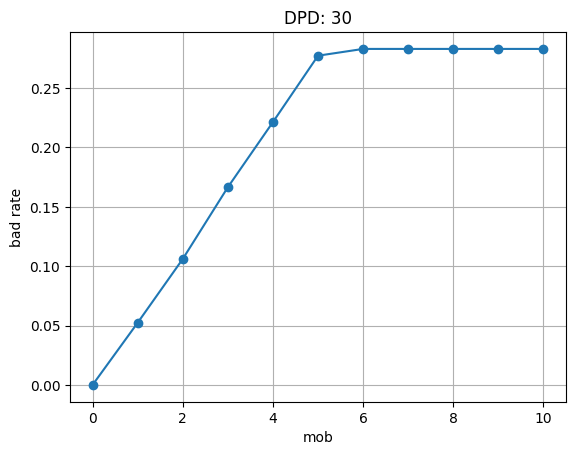

In [86]:
# set dpd label definition
dpd = 30

# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [87]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

## Build gold table for labels

In [88]:
# create bronze datalake
gold_label_store_directory = "datamart/gold/label_store/"

if not os.path.exists(gold_label_store_directory):
    os.makedirs(gold_label_store_directory)

In [89]:
# run gold backfill
for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6)


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530
saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031
saved to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537
saved to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047
saved to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568
saved to: datamart/gold/label_store/gold_label_store_2023_05_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet row count: 3085
saved to: datamart/gold/label_store/gold_label_store_2023_06_01.parquet
loaded from

saved to: datamart/gold/label_store/gold_label_store_2023_11_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_12_01.parquet row count: 5428
saved to: datamart/gold/label_store/gold_label_store_2023_12_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_01_01.parquet row count: 5412
saved to: datamart/gold/label_store/gold_label_store_2024_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_02_01.parquet row count: 5424
saved to: datamart/gold/label_store/gold_label_store_2024_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_03_01.parquet row count: 5425
saved to: datamart/gold/label_store/gold_label_store_2024_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_04_01.parquet row count: 5417
saved to: datamart/gold/label_store/gold_label_store_2024_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_05_01.parquet row count: 5391
saved to: 

In [90]:
utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6).dtypes


loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531
saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


[('loan_id', 'string'),
 ('Customer_ID', 'string'),
 ('label', 'int'),
 ('label_def', 'string'),
 ('snapshot_date', 'date')]

## inspect label store

In [91]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 8974
+--------------------+-----------+-----+----------+-------------+
|             loan_id|Customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x1037_2023_0...| CUS_0x1037|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1069_2023_0...| CUS_0x1069|    0|30dpd_6mob|   2023-07-01|
|CUS_0x114a_2023_0...| CUS_0x114a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1184_2023_0...| CUS_0x1184|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1297_2023_0...| CUS_0x1297|    1|30dpd_6mob|   2023-07-01|
|CUS_0x12fb_2023_0...| CUS_0x12fb|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1325_2023_0...| CUS_0x1325|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1375_2023_0...| CUS_0x1375|    1|30dpd_6mob|   2023-07-01|
|CUS_0x13a8_2023_0...| CUS_0x13a8|    0|30dpd_6mob|   2023-07-01|
|CUS_0x13ef_2023_0...| CUS_0x13ef|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1440_2023_0...| CUS_0x1440|    0|30dpd_6mob|   2023-0

In [92]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



## Build Gold Feature Store

In [93]:
silver_loan_daily_directory = "datamart/silver/loan_daily/"
silver_financials_directory = "datamart/silver/financials/"
silver_attributes_directory = "datamart/silver/attributes/"
silver_clickstream_directory = "datamart/silver/clickstream/"

gold_feature_store_directory = "datamart/gold/feature_store/"

In [94]:
for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_gold_feature_table(
    date_str,
    silver_loan_daily_directory,
    silver_financials_directory,
    silver_attributes_directory,
    silver_clickstream_directory,
    gold_feature_store_directory,
    spark
)

loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530
loans originating this month: 530
saved to: datamart/gold/feature_store/gold_feature_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031
loans originating this month: 501
saved to: datamart/gold/feature_store/gold_feature_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537
loans originating this month: 506
saved to: datamart/gold/feature_store/gold_feature_store_2023_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047
loans originating this month: 510
saved to: datamart/gold/feature_store/gold_feature_store_2023_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568
loans originating this month: 521
saved to: datamart/gold/feature_store/gold_feature_store_2023_

In [95]:
utils.data_processing_gold_table.process_gold_feature_table(
    date_str,
    silver_loan_daily_directory,
    silver_financials_directory,
    silver_attributes_directory,
    silver_clickstream_directory,
    gold_feature_store_directory,
    spark
).dtypes

loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531
loans originating this month: 515
saved to: datamart/gold/feature_store/gold_feature_store_2024_12_01.parquet


[('Customer_ID', 'string'),
 ('loan_id', 'string'),
 ('loan_start_date', 'date'),
 ('tenure', 'int'),
 ('loan_amt', 'float'),
 ('Scheduled_Installment_Amt', 'float'),
 ('snapshot_date', 'date'),
 ('Annual_Income', 'double'),
 ('Monthly_Inhand_Salary', 'double'),
 ('Num_Bank_Accounts', 'int'),
 ('Num_Credit_Card', 'int'),
 ('Interest_Rate', 'int'),
 ('Num_of_Loan', 'int'),
 ('Type_of_Loan', 'string'),
 ('Delay_from_due_date', 'int'),
 ('Num_of_Delayed_Payment', 'int'),
 ('Changed_Credit_Limit', 'double'),
 ('Num_Credit_Inquiries', 'double'),
 ('Credit_Mix', 'string'),
 ('Outstanding_Debt', 'double'),
 ('Credit_Utilization_Ratio', 'double'),
 ('Payment_of_Min_Amount', 'string'),
 ('Total_EMI_per_month', 'double'),
 ('Amount_invested_monthly', 'double'),
 ('Payment_Behaviour', 'string'),
 ('Monthly_Balance', 'double'),
 ('Credit_History_Age_Months', 'int'),
 ('Age', 'int'),
 ('Occupation', 'string'),
 ('fe_1', 'double'),
 ('fe_2', 'double'),
 ('fe_3', 'double'),
 ('fe_4', 'double'),
 ('fe

In [96]:
folder_path = gold_feature_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 11974
+-----------+--------------------+---------------+------+--------+-------------------------+-------------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------------------+---+-------------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+---------------------------+-------------------+--------------------+--------------------------+-----------------------+--------------------+--------------+-------------------+-----------------------+-------------------+----------------------------+--------+----------------+----------------+-----------------------+
|Customer_ID|     

## Charts

In [97]:
# load full gold label store
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
label_df = spark.read.option("header", "true").parquet(*files_list)
label_pdf = label_df.toPandas()
print("row_count:", len(label_pdf))
label_pdf.head()

row_count: 8974


,loan_id,Customer_ID,label,label_def,snapshot_date
0,CUS_0x1037_2023_01_01,CUS_0x1037,0,30dpd_6mob,2023-07-01
1,CUS_0x1069_2023_01_01,CUS_0x1069,0,30dpd_6mob,2023-07-01
2,CUS_0x114a_2023_01_01,CUS_0x114a,0,30dpd_6mob,2023-07-01
3,CUS_0x1184_2023_01_01,CUS_0x1184,0,30dpd_6mob,2023-07-01
4,CUS_0x1297_2023_01_01,CUS_0x1297,1,30dpd_6mob,2023-07-01


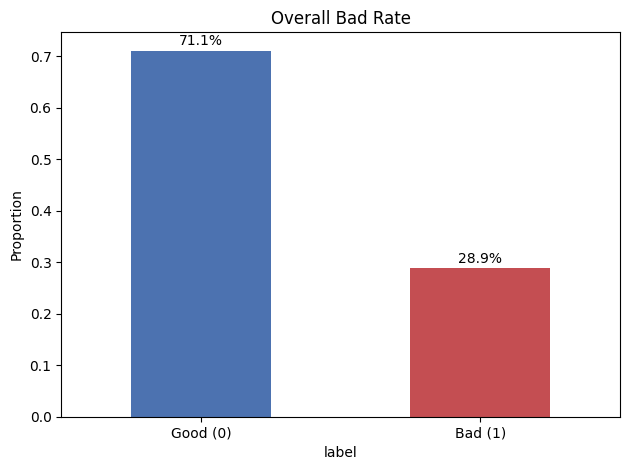

In [98]:
# overall bad rate (label distribution)
bad_rate = label_pdf['label'].value_counts(normalize=True).sort_index()

ax = bad_rate.plot(kind='bar', color=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['Good (0)', 'Bad (1)'], rotation=0)
plt.title('Overall Bad Rate')
plt.ylabel('Proportion')
for i, v in enumerate(bad_rate):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.show()

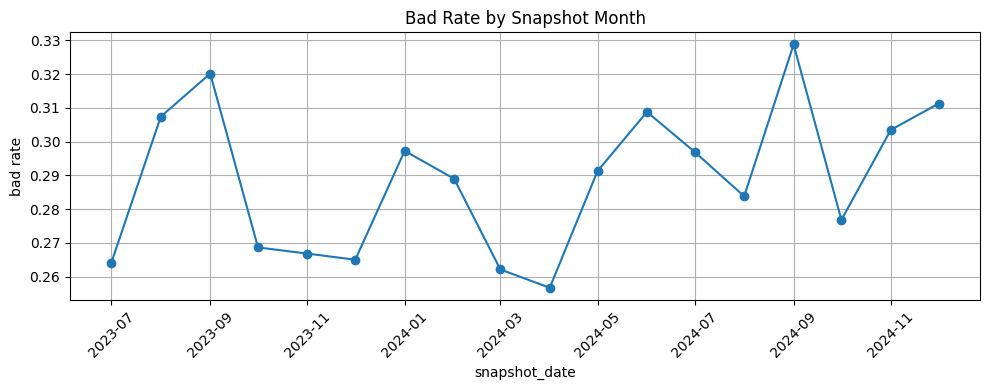

In [99]:
# bad rate by origination/monitoring snapshot month -- checks for drift over time
by_month = label_pdf.groupby('snapshot_date')['label'].mean().sort_index()

by_month.plot(kind='line', marker='o', figsize=(10, 4))
plt.title('Bad Rate by Snapshot Month')
plt.xlabel('snapshot_date')
plt.ylabel('bad rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [100]:
# load full gold feature store
folder_path = gold_feature_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
feature_df = spark.read.option("header", "true").parquet(*files_list)
feature_pdf = feature_df.toPandas()
print("row_count:", len(feature_pdf))

# join on loan_id -- NEVER on snapshot_date (see warning above)
merged_pdf = feature_pdf.merge(
    label_pdf[['loan_id', 'label']],
    on='loan_id',
    how='inner'
)
print("merged row_count:", len(merged_pdf))
merged_pdf.head()

row_count: 11974
merged row_count: 8974


,Customer_ID,loan_id,loan_start_date,tenure,loan_amt,Scheduled_Installment_Amt,snapshot_date,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Post_EMI_Slack,Loan_Type_Diversity,Credit_Utilization_Band,Credit_History_Band,Recent_Credit_Expansion_Flag,Age_Band,Occupation_Group,Clickstream_Mean,Clickstream_Vector_Norm,label
0,CUS_0x1048,CUS_0x1048_2024_02_01,2024-02-01,10,10000.0,0.0,2024-02-01,42387.54,3680.30,3.0,...,3454.42,5,Low,Established,1,25to39,Professional,102.58,466.58,1
1,CUS_0x10c0,CUS_0x10c0_2024_02_01,2024-02-01,10,10000.0,0.0,2024-02-01,49454.13,4328.18,8.0,...,4254.83,2,Low,Established,1,25to39,Professional,96.32,453.55,1
2,CUS_0x115c,CUS_0x115c_2024_02_01,2024-02-01,10,10000.0,0.0,2024-02-01,41695.76,3401.65,6.0,...,3098.84,5,Low,Established,1,Under25,Professional,102.50,478.47,0
3,CUS_0x12b6,CUS_0x12b6_2024_02_01,2024-02-01,10,10000.0,0.0,2024-02-01,67104.12,5829.01,9.0,...,5563.99,4,Low,New,1,Under25,Creative,110.80,512.28,0
4,CUS_0x12b8,CUS_0x12b8_2024_02_01,2024-02-01,10,10000.0,0.0,2024-02-01,15906.40,1350.53,9.0,...,1258.64,5,Medium,Established,1,25to39,Professional,92.86,431.46,1


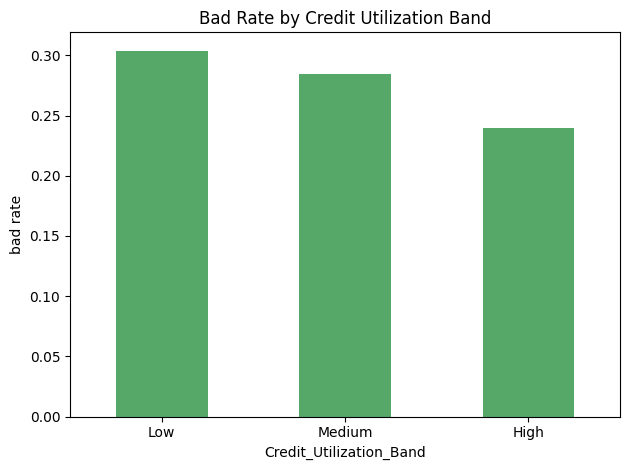

In [101]:
# bad rate by Credit_Utilization_Band -- validates whether the 30/50 cutoffs separate risk
band_order = ['Low', 'Medium', 'High']
by_util_band = merged_pdf.groupby('Credit_Utilization_Band')['label'].mean().reindex(band_order)

by_util_band.plot(kind='bar', color='#55A868')
plt.title('Bad Rate by Credit Utilization Band')
plt.ylabel('bad rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

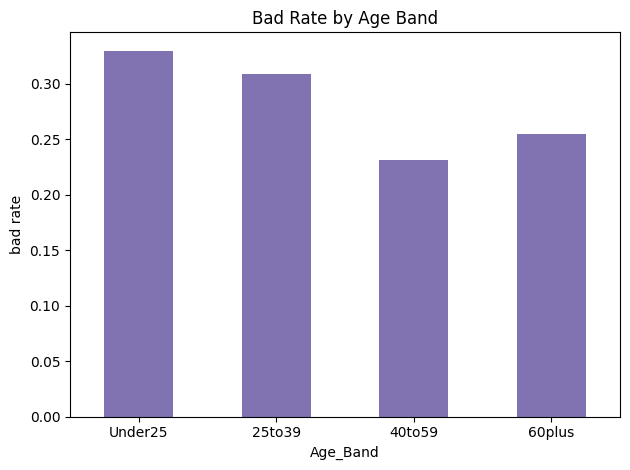

In [102]:
# bad rate by Age_Band
age_band_order = ['Under25', '25to39', '40to59', '60plus']
by_age_band = merged_pdf.groupby('Age_Band')['label'].mean().reindex(age_band_order)

by_age_band.plot(kind='bar', color='#8172B2')
plt.title('Bad Rate by Age Band')
plt.ylabel('bad rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

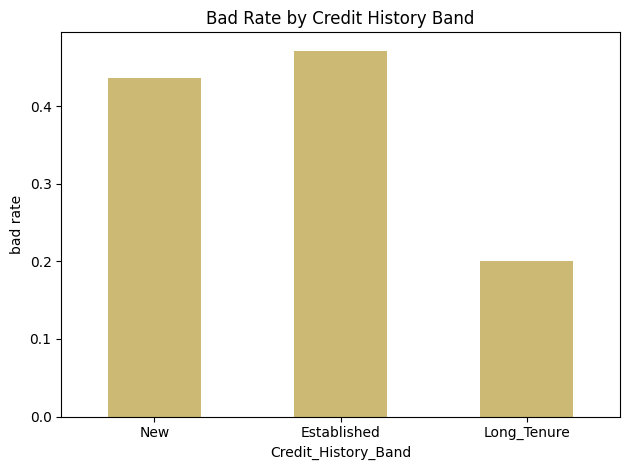

In [103]:
# bad rate by Credit_History_Band
hist_band_order = ['New', 'Established', 'Long_Tenure']
by_hist_band = merged_pdf.groupby('Credit_History_Band')['label'].mean().reindex(hist_band_order)

by_hist_band.plot(kind='bar', color='#CCB974')
plt.title('Bad Rate by Credit History Band')
plt.ylabel('bad rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

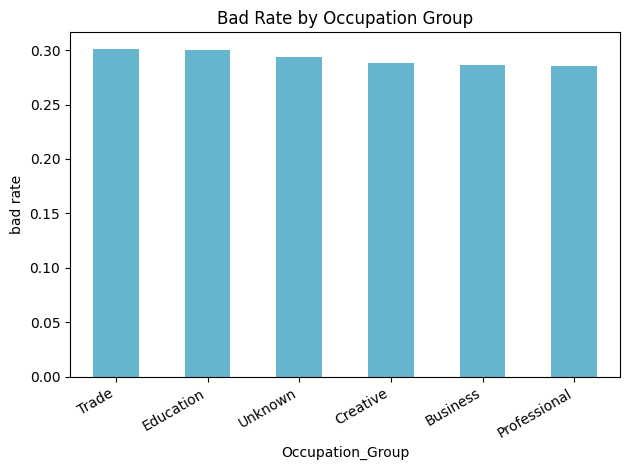

In [104]:
# bad rate by Occupation_Group
by_occ = merged_pdf.groupby('Occupation_Group')['label'].mean().sort_values(ascending=False)

by_occ.plot(kind='bar', color='#64B5CD')
plt.title('Bad Rate by Occupation Group')
plt.ylabel('bad rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

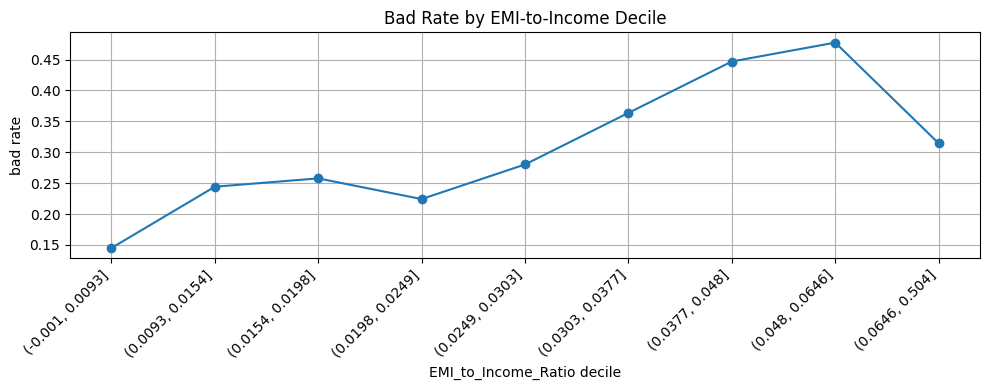

In [105]:
# EMI_to_Income_Ratio vs bad rate -- binned into deciles to check for monotonic signal
merged_pdf['EMI_to_Income_Decile'] = pd.qcut(merged_pdf['EMI_to_Income_Ratio'], 10, duplicates='drop')
by_emi_decile = merged_pdf.groupby('EMI_to_Income_Decile', observed=True)['label'].mean()

by_emi_decile.plot(kind='line', marker='o', figsize=(10, 4))
plt.title('Bad Rate by EMI-to-Income Decile')
plt.xlabel('EMI_to_Income_Ratio decile')
plt.ylabel('bad rate')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

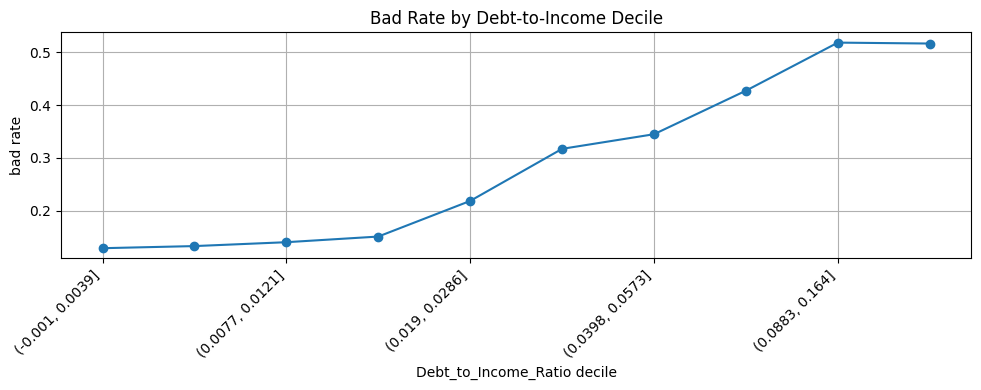

In [106]:
# Debt_to_Income_Ratio vs bad rate -- same decile-binning approach
merged_pdf['Debt_to_Income_Decile'] = pd.qcut(merged_pdf['Debt_to_Income_Ratio'], 10, duplicates='drop')
by_debt_decile = merged_pdf.groupby('Debt_to_Income_Decile', observed=True)['label'].mean()

by_debt_decile.plot(kind='line', marker='o', figsize=(10, 4))
plt.title('Bad Rate by Debt-to-Income Decile')
plt.xlabel('Debt_to_Income_Ratio decile')
plt.ylabel('bad rate')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [107]:
def null_pct_pdf(spark_df):
    total = spark_df.count()
    null_counts = spark_df.select([
        spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in spark_df.columns
    ]).toPandas().T
    null_counts.columns = ['null_count']
    null_counts['null_pct'] = null_counts['null_count'] / total * 100
    return null_counts.sort_values('null_pct', ascending=False)

# re-read each silver table in full (all months) for a global missingness view
def load_full_silver(directory):
    files_list = [directory+os.path.basename(f) for f in glob.glob(os.path.join(directory, '*'))]
    return spark.read.option("header", "true").parquet(*files_list)

financials_null_pdf = null_pct_pdf(load_full_silver(silver_financials_directory))
attributes_null_pdf = null_pct_pdf(load_full_silver(silver_attributes_directory))
clickstream_null_pdf = null_pct_pdf(load_full_silver(silver_clickstream_directory))

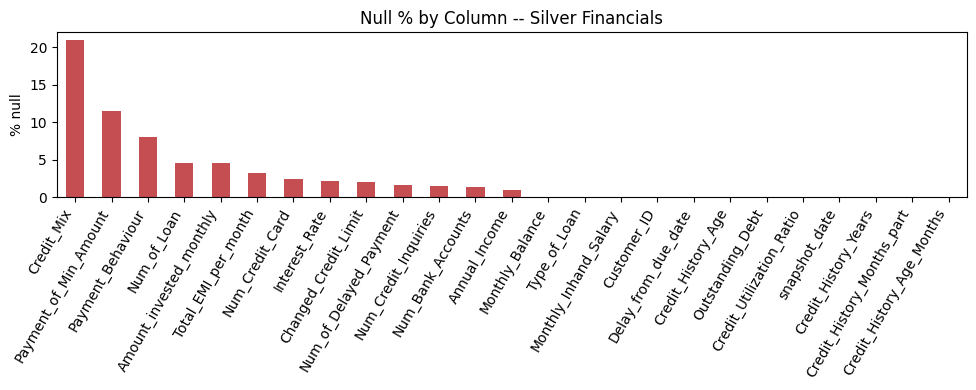

In [108]:
# missingness -- financials table
financials_null_pdf['null_pct'].plot(kind='bar', figsize=(10, 4), color='#C44E52')
plt.title('Null % by Column -- Silver Financials')
plt.ylabel('% null')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

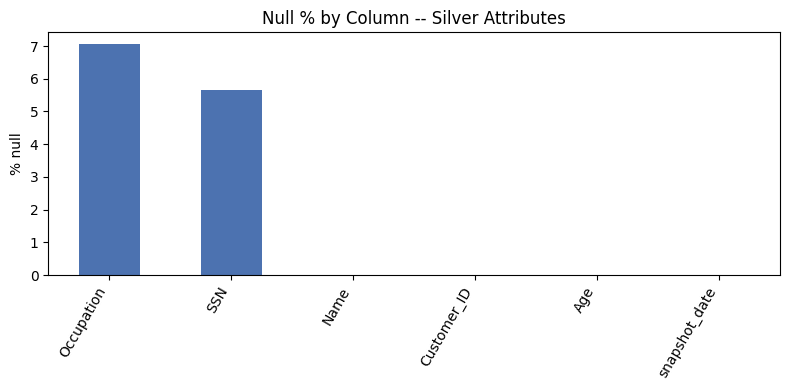

In [109]:
# missingness -- attributes table
attributes_null_pdf['null_pct'].plot(kind='bar', figsize=(8, 4), color='#4C72B0')
plt.title('Null % by Column -- Silver Attributes')
plt.ylabel('% null')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

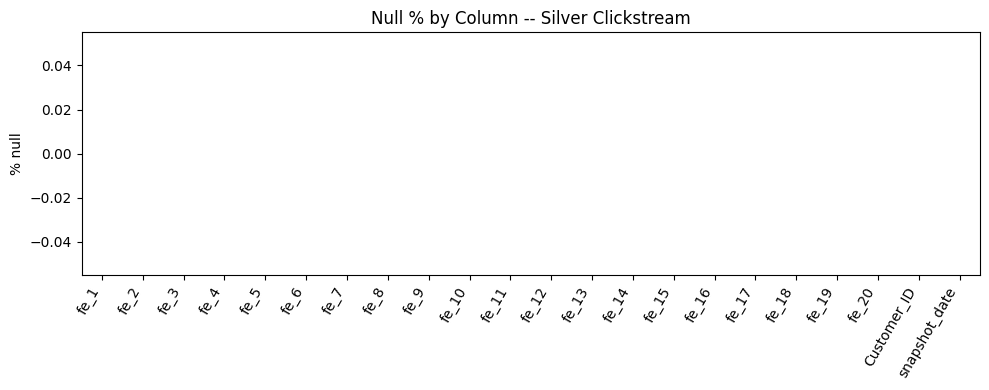

In [110]:
# missingness -- clickstream table (fe_ columns only, plus Customer_ID)
clickstream_null_pdf['null_pct'].plot(kind='bar', figsize=(10, 4), color='#55A868')
plt.title('Null % by Column -- Silver Clickstream')
plt.ylabel('% null')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

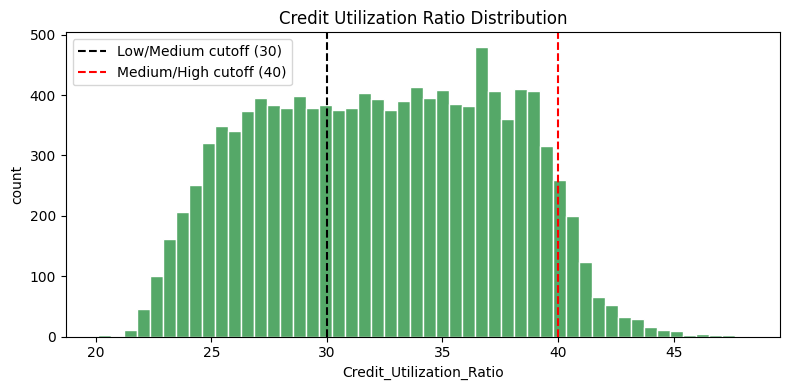

In [115]:
# Credit_Utilization_Ratio distribution with the 30/50 band cutoffs overlaid
plt.figure(figsize=(8, 4))
plt.hist(feature_pdf['Credit_Utilization_Ratio'].dropna(), bins=50, color='#55A868', edgecolor='white')
plt.axvline(30, color='black', linestyle='--', label='Low/Medium cutoff (30)')
plt.axvline(40, color='red', linestyle='--', label='Medium/High cutoff (40)')
plt.title('Credit Utilization Ratio Distribution')
plt.xlabel('Credit_Utilization_Ratio')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

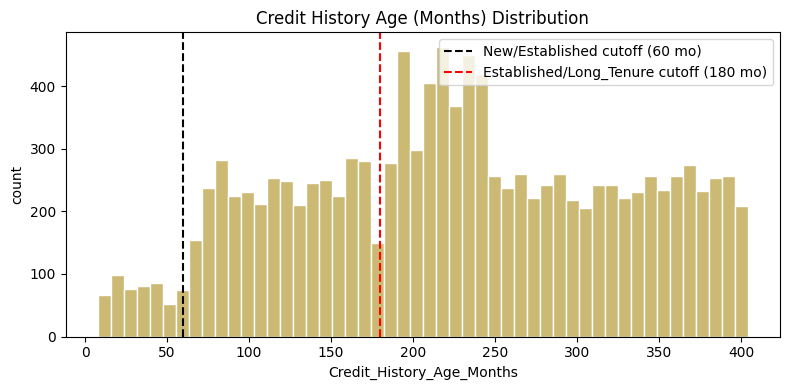

In [112]:
# Credit_History_Age_Months distribution with the 60/180 band cutoffs overlaid
plt.figure(figsize=(8, 4))
plt.hist(feature_pdf['Credit_History_Age_Months'].dropna(), bins=50, color='#CCB974', edgecolor='white')
plt.axvline(60, color='black', linestyle='--', label='New/Established cutoff (60 mo)')
plt.axvline(180, color='red', linestyle='--', label='Established/Long_Tenure cutoff (180 mo)')
plt.title('Credit History Age (Months) Distribution')
plt.xlabel('Credit_History_Age_Months')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

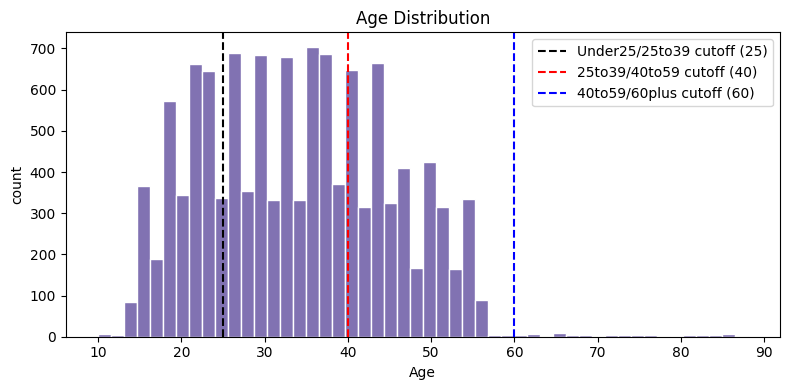

In [113]:
# Age distribution with the 25/40/60 band cutoffs overlaid
plt.figure(figsize=(8, 4))
plt.hist(feature_pdf['Age'].dropna(), bins=50, color='#8172B2', edgecolor='white')
plt.axvline(25, color='black', linestyle='--', label='Under25/25to39 cutoff (25)')
plt.axvline(40, color='red', linestyle='--', label='25to39/40to59 cutoff (40)')
plt.axvline(60, color='blue', linestyle='--', label='40to59/60plus cutoff (60)')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

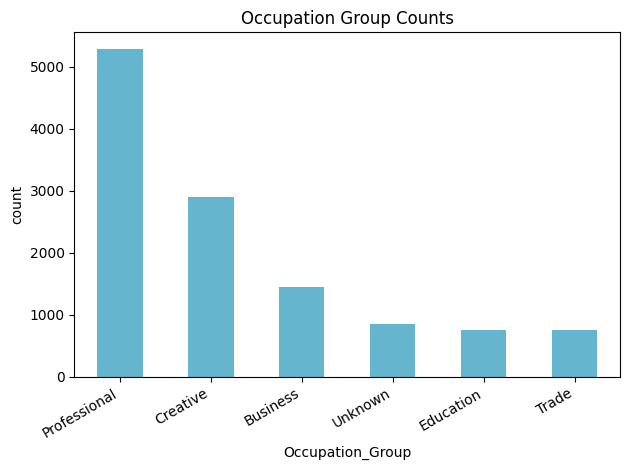

In [114]:
# Occupation_Group counts -- checks whether "Unknown" dominates
occ_counts = feature_pdf['Occupation_Group'].value_counts()

occ_counts.plot(kind='bar', color='#64B5CD')
plt.title('Occupation Group Counts')
plt.ylabel('count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()